In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import netCDF4
import datetime as dt
from mpl_toolkits.basemap import Basemap
import gsw
%matplotlib inline
import glob
import pandas as pd
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime
import os
import datetime

In [3]:
import numpy as np
import netCDF4 as nc

file = '/data0/user/aprigent/ICES/dfdcbdf5-e301-4837-be35-7a61d436528e.csv'
with open(file, 'r') as f:
    text1 = f.readlines()

ncol = [len(l.split(',')) for l in text1]

i27 = np.where((np.array(ncol) == 27) & (np.array([not l.startswith('//') and not l.startswith('Cruise') for l in text1])))[0]
lon, lat = [], []
year, mon, day, h, m = [], [], [], [], []
d, t, s, o, chl, cond = [], [], [], [], [], []
index_time_prob = []
for i in i27:
    cols = text1[i].strip().split(',')
    try:
        lon.append(float(cols[4]))
        lat.append(float(cols[5]))
        # parse date

        
        date = cols[3]  # could be '1987-09-16T09:05Z' or '1983-04-13'
        if 'T' in date:
            d_part, t_part = date.split('T')
            hh, mm = t_part.replace('Z', '').split(':')
        else:
            d_part = date
            hh, mm = 0, 0  # default to midnight if no time given
        
        y, mo, da = d_part.split('-')
        # da, time = rest.split('T')
        # hh, mm = time.replace('Z', '').split(':')
        year.append(int(y))
        mon.append(int(mo))
        day.append(int(da))

        # h.append(int(hh)); m.append(int(mm))
        d.append(float(cols[15]) if cols[15] else np.nan)
        t.append(float(cols[17]) if cols[17] else np.nan)
        s.append(float(cols[19]) if cols[19] else np.nan)
        o.append(float(cols[21]) if cols[21] else np.nan)
        chl.append(float(cols[23]) if cols[23] else np.nan)
        cond.append(float(cols[25]) if cols[25] else np.nan)
    except ValueError:

        index_time_prob.append(i)
        continue

# remove outliers

In [4]:

s_tmp = np.array(s)
s0 = np.where(np.logical_and(s_tmp>0,s_tmp<40))[0]

s_new = s_tmp[s0]
lons = np.array(lon)[s0]
lats = np.array(lat)[s0]
years = np.array(year)[s0]
mons = np.array(mon)[s0]
days = np.array(day)[s0]
ds = np.array(d)[s0]

t_tmp = np.array(t)
t0 = np.where(np.logical_and(t_tmp>-2,t_tmp<30))[0]
t_new = np.array(t_tmp)[t0]
lont = np.array(lon)[t0]
latt = np.array(lat)[t0]
yeart = np.array(year)[t0]
mont = np.array(mon)[t0]
dayt = np.array(day)[t0]
dt = np.array(d)[t0]

(array([6.9540000e+03, 1.8000000e+02, 1.2400000e+02, 1.7900000e+02,
        4.0500000e+02, 1.4500000e+03, 8.3710000e+03, 1.2276300e+05,
        3.2561056e+07, 3.0300000e+02]),
 array([ 0.0469 ,  4.03702,  8.02714, 12.01726, 16.00738, 19.9975 ,
        23.98762, 27.97774, 31.96786, 35.95798, 39.9481 ]),
 <BarContainer object of 10 artists>)

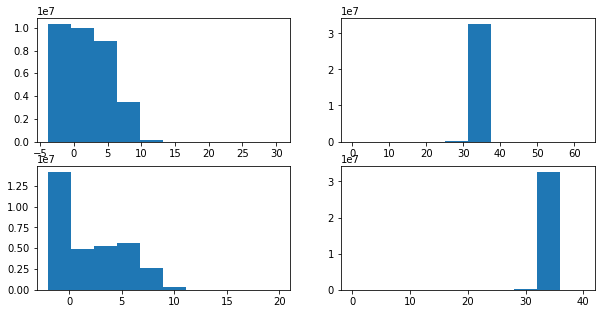

In [5]:
f,ax = plt.subplots(2,2,figsize=[10,5])
ax=ax.ravel()


ax[0].hist(t_tmp)
ax[1].hist(s_tmp)
ax[2].hist(t_new)
ax[3].hist(s_new)

# Save the data

In [8]:
timet = [datetime.datetime(int(yeart[i]), int(mont[i]), int(dayt[i])).toordinal() for i in range(len(lont))]

ds_temp = xr.Dataset(
    {
        'date':        (['JULD'], np.array(timet),  {'long_name': 'observation date', 'units': 'days since 0001-01-01', 'calendar': 'proleptic_gregorian'}),
        'latitude':    (['JULD'], latt,              {'long_name': 'latitude',  'units': 'degrees_north', 'standard_name': 'latitude'}),
        'longitude':   (['JULD'], lont,              {'long_name': 'longitude', 'units': 'degrees_east',  'standard_name': 'longitude'}),
        'temperature': (['JULD'], t_new,             {'long_name': 'sea water temperature T90', 'units': 'degC', 'standard_name': 'sea_water_temperature'}),
        'depth':       (['JULD'], dt,                {'long_name': 'depth', 'units': 'm', 'standard_name': 'depth', 'positive': 'down'}),
    },
    coords={'JULD': (['JULD'], np.array(timet), {'long_name': 'observation date', 'units': 'days since 0001-01-01', 'calendar': 'proleptic_gregorian'})},
)

ds_temp.attrs = {
    'title':          'ICES hydrographic observations',
    'source':         'ICES data portal (ODV CSV export)',
    'contact':        'arthur.prigent@univ-brest.fr',
    'reference_date': '0001-01-01 (python datetime ordinal)',
    'history':        f'Created {datetime.datetime.now().strftime("%Y-%m-%d")} from read_ICES_CTD_to_netcdf.ipynb',
}

In [9]:
ds_temp

<xarray.Dataset>
Dimensions:      (JULD: 32825702)
Coordinates:
  * JULD         (JULD) int64 725630 725630 725630 ... 739179 739179 739179
Data variables:
    date         (JULD) int64 725630 725630 725630 ... 739179 739179 739179
    latitude     (JULD) float64 65.5 65.5 65.5 65.5 ... 71.11 71.11 71.11 71.11
    longitude    (JULD) float64 10.43 10.43 10.43 10.43 ... -16.37 -16.37 -16.37
    temperature  (JULD) float64 11.11 11.11 11.11 11.11 ... 5.013 5.013 5.012
    depth        (JULD) float64 9.0 10.0 11.0 12.0 ... 384.8 385.8 386.7 387.7
Attributes:
    title:           ICES hydrographic observations
    source:          ICES data portal (ODV CSV export)
    contact:         arthur.prigent@univ-brest.fr
    reference_date:  0001-01-01 (python datetime ordinal)
    history:         Created 2026-04-29 from read_ICES_CTD_to_netcdf.ipynb

In [10]:
times = [datetime.datetime(int(years[i]), int(mons[i]), int(days[i])).toordinal() for i in range(len(lons))]

ds_psal = xr.Dataset(
    {
        'date':      (['JULD'], np.array(times), {'long_name': 'observation date', 'units': 'days since 0001-01-01', 'calendar': 'proleptic_gregorian'}),
        'latitude':  (['JULD'], lats,             {'long_name': 'latitude',  'units': 'degrees_north', 'standard_name': 'latitude'}),
        'longitude': (['JULD'], lons,             {'long_name': 'longitude', 'units': 'degrees_east',  'standard_name': 'longitude'}),
        'salinity':  (['JULD'], s_new,            {'long_name': 'practical salinity PSS78', 'units': '1', 'standard_name': 'sea_water_practical_salinity'}),
        'depth':     (['JULD'], ds,               {'long_name': 'depth', 'units': 'm', 'standard_name': 'depth', 'positive': 'down'}),
    },
    coords={'JULD': (['JULD'], np.array(times), {'long_name': 'observation date', 'units': 'days since 0001-01-01', 'calendar': 'proleptic_gregorian'})},
)

ds_psal.attrs = {
    'title':          'ICES hydrographic observations - salinity',
    'source':         'ICES data portal (ODV CSV export)',
    'contact':        'arthur.prigent@univ-brest.fr',
    'reference_date': '0001-01-01 (python datetime ordinal)',
    'history':        f'Created {datetime.datetime.now().strftime("%Y-%m-%d")} from read_ICES_CTD_to_netcdf.ipynb',
}

In [11]:
ds_temp.to_netcdf('/data0/user/aprigent/ICES/ICES_profiles_temperature.nc')

In [12]:
ds_psal.to_netcdf('/data0/user/aprigent/ICES/ICES_profiles_salinity.nc')